In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
# from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor



In [10]:
file_path = 'dv0_witoutstraw.xlsx'  # Use the correct path for your environment
data = pd.read_excel(file_path)

data = data[data['Label'] == 1]

grouped_data = data.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),  # Count of rows (time steps)
    dV=('dV', 'first'),  # Taking the first dV value for each group
    Label=('Label', 'first')  # Assuming the label is consistent, take the first
).reset_index()

print("\nGrouped Data Sample:")
print(grouped_data.head())

X = grouped_data[['time_steps']]  # Features
y = grouped_data['dV']             # Target variable


print("\nFeatures (X):")
print(X.head(50))
print("\nTarget (y):")
print(y.head(50))


Grouped Data Sample:
   Participant_ID  sip_id  time_steps         dV  Label
0               6       1          26  69.904762      1
1               6       2          26  58.000000      1
2               6       3          27  61.904762      1
3               6       4          29  68.857143      1
4               6       5          23  44.571429      1

Features (X):
    time_steps
0           26
1           26
2           27
3           29
4           23
5           13
6           24
7           21
8           21
9           27
10          29
11          29
12          20
13          21
14          16
15          15
16          16
17          10
18          10
19          10
20           7
21           9
22           9
23          17
24           8
25          11
26           8
27          20
28          27
29          43
30          60
31          48
32          29
33          39
34          17
35          13
36          11
37          14
38          12
39          16
40          

In [11]:
train_size = int(0.8 * len(grouped_data))  # 80% of the data for training
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 396.6519
Root Mean Squared Error (RMSE): 19.9161
R-squared (R²): -0.2763
Root Mean Squared Percentage Error (RMSPE): 68.5769%
     Actual  Predicted
252    38.1  25.331136
253    36.0  25.331136
254    33.7  25.331136
255    23.0  32.747455
256    13.9  21.093239


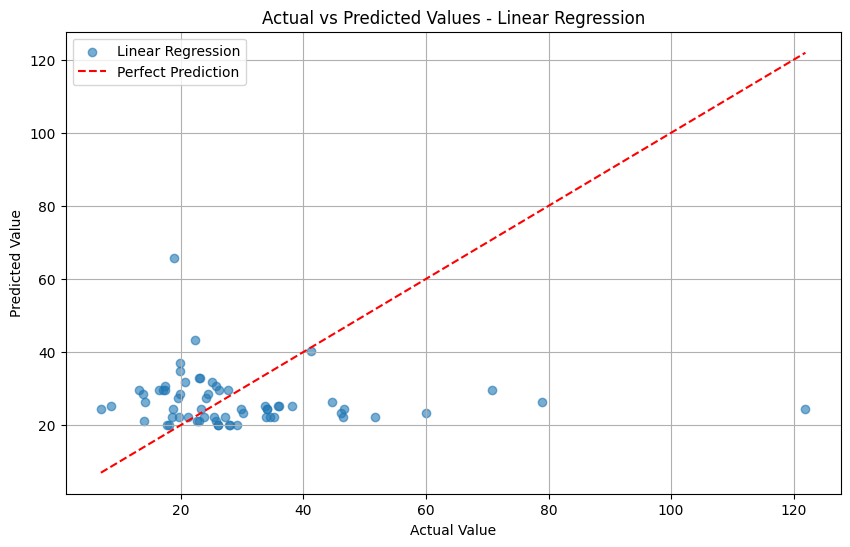


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 397.9539
Root Mean Squared Error (RMSE): 19.9488
R-squared (R²): -0.2805
Root Mean Squared Percentage Error (RMSPE): 47.2523%
     Actual  Predicted
252    38.1  20.423206
253    36.0  20.423206
254    33.7  20.423206
255    23.0  24.755181
256    13.9  18.910495


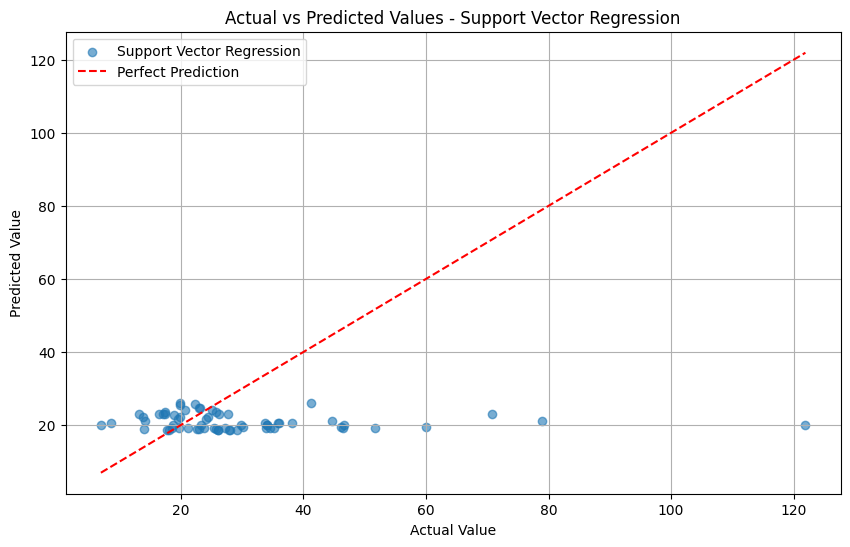


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 569.7146
Root Mean Squared Error (RMSE): 23.8687
R-squared (R²): -0.8332
Root Mean Squared Percentage Error (RMSPE): 94.2902%
     Actual  Predicted
252    38.1  23.496148
253    36.0  23.496148
254    33.7  23.496148
255    23.0  30.339009
256    13.9  16.070138


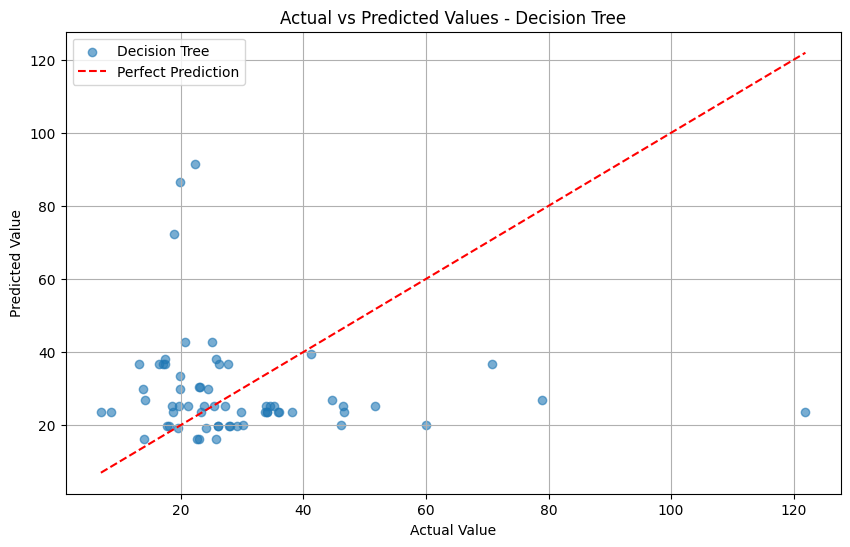


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 527.6746
Root Mean Squared Error (RMSE): 22.9712
R-squared (R²): -0.6980
Root Mean Squared Percentage Error (RMSPE): 89.0710%
     Actual  Predicted
252    38.1  23.180604
253    36.0  23.180604
254    33.7  23.180604
255    23.0  30.861650
256    13.9  15.378282


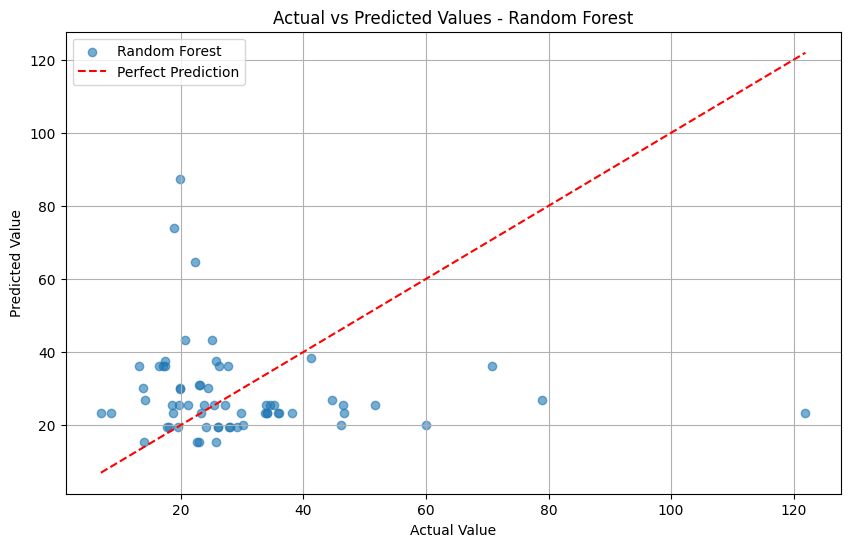


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 549.1647
Root Mean Squared Error (RMSE): 23.4343
R-squared (R²): -0.7671
Root Mean Squared Percentage Error (RMSPE): 91.3519%
     Actual  Predicted
252    38.1  23.419511
253    36.0  23.419511
254    33.7  23.419511
255    23.0  31.145434
256    13.9  17.149494


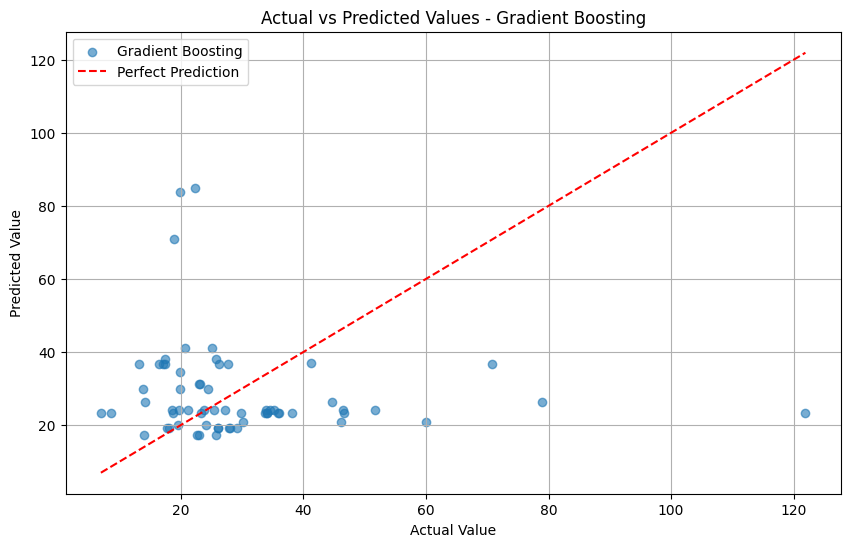


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 608.0508
Root Mean Squared Error (RMSE): 24.6587
R-squared (R²): -0.9566
Root Mean Squared Percentage Error (RMSPE): 95.2109%
     Actual  Predicted
252    38.1  22.316622
253    36.0  22.316622
254    33.7  22.316622
255    23.0  22.932675
256    13.9   8.522101


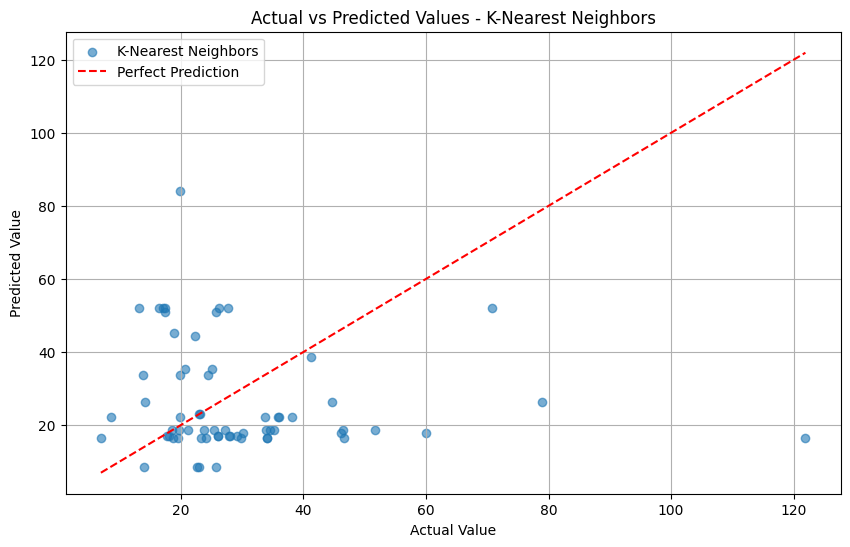

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(comparison_df.head(5))

    # Plotting Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()